1. Carga de datos:

In [11]:
import pandas as pd
import sys
import os
import importlib.util

# Configuración de rutas para acceder a src
path_carpeta_src = os.path.abspath('../src')
sys.path.append(path_carpeta_src)

# Carga del módulo para usar las funciones de GRÁFICOS
path_archivo = os.path.join(path_carpeta_src, "retail-sales-analysis_P4.py")
spec = importlib.util.spec_from_file_location("modulo_p4", path_archivo)
modulo_p4 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(modulo_p4)

# Carga de dataset procesado de la Parte III
datos = pd.read_csv('../data/retail_sales_final_P3.csv')

print("Éxito: Datos de la Parte III cargados y módulo de visualización listo.")
datos.head()

Éxito: Datos de la Parte III cargados y módulo de visualización listo.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Ingreso Total,Ventas Normalizadas,Categoria Venta,Mes,Rango_Etario,Desviacion_Media,Puntos_Lealtad
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.06,Media,11,Adulto,-317.475570,0.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.49,Media,2,Adulto,556.752137,100.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.00,Baja,1,Senior,-428.786550,0.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.24,Media,5,Adulto,56.752137,25.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.04,Baja,5,Adulto,-367.475570,0.0


** Exporar si existen duplicados

In [12]:
print("--- BUSCANDO REGISTROS REPETIDOS ---")

filas_vistas = []
duplicados_encontrados = []

for fila in datos:
    # Convertir la fila a una lista
    fila_lista = list(fila)
    
    if fila_lista in filas_vistas:
        duplicados_encontrados.append(fila_lista)
    else:
        filas_vistas.append(fila_lista)

print(f"Cantidad de filas duplicadas: {len(duplicados_encontrados)}")

if len(duplicados_encontrados) > 0:
    print("Se encontraron datos repetidos. Es necesario eliminarlos para no alterar las estadísticas.")

--- BUSCANDO REGISTROS REPETIDOS ---
Cantidad de filas duplicadas: 0


3. Análisis Descriptivo y Visualización

3.1 Estadísticas Descriptivas

In [ ]:
# Estadísticas para variables numéricas (Edad, Cantidad, Total Amount, Puntos_Lealtad)
stats_numericas = datos.describe()

# Estadísticas para categorías (Gender, Product Category, Categoria Venta, Rango_Etario)
stats_categoricas = datos.describe(include=['object'])

print("--- ESTADÍSTICAS VARIABLES NUMÉRICAS ---")
display(stats_numericas.round(2))

print("\n--- ESTADÍSTICAS VARIABLES CATEGÓRICAS ---")
display(stats_categoricas)

--- ESTADÍSTICAS VARIABLES NUMÉRICAS ---


C:\Users\ivanc\AppData\Local\Temp\ipykernel_53324\2813532279.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  stats_categoricas = datos.describe(include=['object'])


,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Ingreso Total,Ventas Normalizadas,Mes,Desviacion_Media,Puntos_Lealtad
count,1000.00,1000.00,1000.00,1000.00,1000.0,1000.0,1000.00,1000.00,1000.00,1000.00
mean,500.50,41.39,2.51,179.89,456.0,456.0,0.22,6.55,0.00,49.78
std,288.82,13.68,1.13,189.68,560.0,560.0,0.28,3.45,559.91,85.39
min,1.00,18.00,1.00,25.00,25.0,25.0,0.00,1.00,-442.48,0.00
25%,250.75,29.00,1.00,30.00,60.0,60.0,0.02,4.00,-392.48,0.00
50%,500.50,42.00,3.00,50.00,135.0,135.0,0.06,6.00,-320.36,0.00
75%,750.25,53.00,4.00,300.00,900.0,900.0,0.44,10.00,432.52,90.00
max,1000.00,64.00,4.00,500.00,2000.0,2000.0,1.00,12.00,1556.75,300.00



--- ESTADÍSTICAS VARIABLES CATEGÓRICAS ---


,Date,Customer ID,Gender,Product Category,Categoria Venta,Rango_Etario
count,1000,1000,1000,1000,1000,1000
unique,345,1000,2,3,3,3
top,2023-05-16,CUST001,Female,Clothing,Baja,Senior
freq,11,1,510,351,457,424


4. Distribución de Variables Numéricas Clave

4.1 Análisis de Ventas

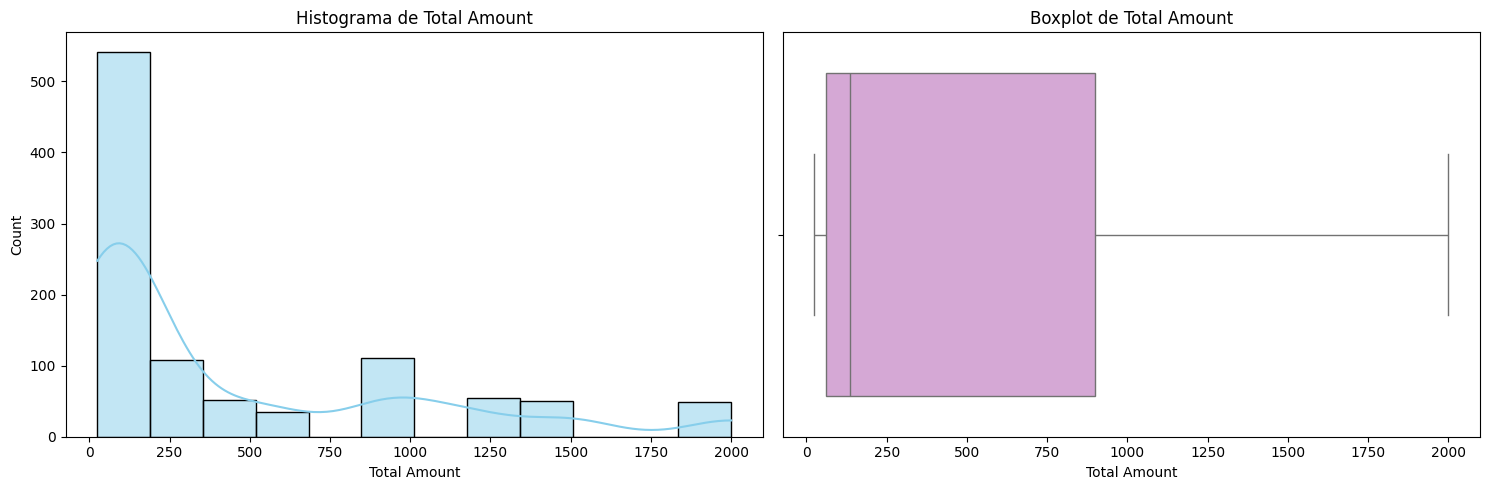

--- ANÁLISIS DE GESTIÓN: VENTAS ---
ESTRATEGIA: Con un ticket promedio de $456.00, la diversificación es clave.
TÁCTICA: El valor máximo es $2000. Impulsar programas VIP.
OPERACIÓN: La mediana es $135.00. Optimizar rapidez para este volumen de transacciones.


In [ ]:
# Visualización
modulo_p4.graficar_distribucion_y_outliers(datos, 'Total Amount')

# Variables para interpretación
media = datos['Total Amount'].mean()
max_val = datos['Total Amount'].max()
mediana = datos['Total Amount'].median()

print(f"--- ANÁLISIS DE GESTIÓN: GASTO TOTAL ---")
print(f"ESTRATEGIA: Con un ticket promedio de ${media:.2f}, la diversificación es clave.")
print(f"TÁCTICA: El valor máximo es ${max_val}. {'Impulsar programas VIP' if max_val > media*2 else 'Falta impulsar el Upselling'}.")
print(f"OPERACIÓN: La mediana es ${mediana:.2f}. Optimizar rapidez para este volumen de transacciones.")

4.2 Análsis Demográfico

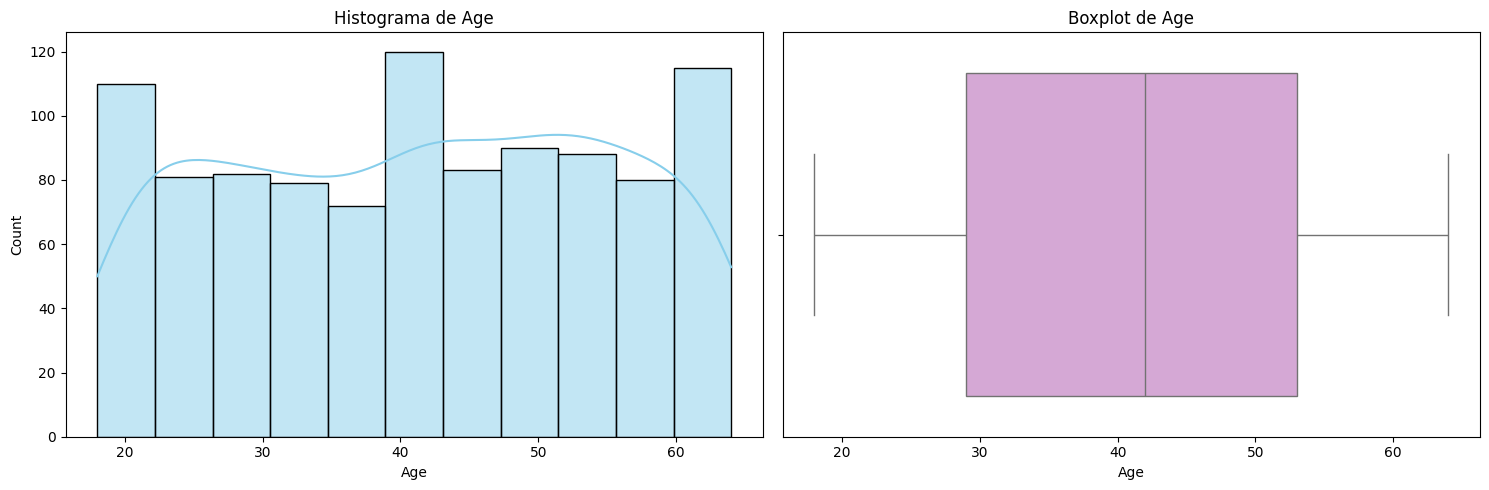

--- ANÁLISIS DE GESTIÓN: AGE ---
ESTRATEGIA: Promedio de edad 41 años. Enfoque en tendencias y frescura.
TÁCTICA: Segmentar campañas para el rango central (IQR) entre 29 y 53 años.
OPERACIÓN: Adaptar accesibilidad de tienda/web al perfil mayoritario (Mediana: 42 años).


In [ ]:
# Visualización
modulo_p4.graficar_distribucion_y_outliers(datos, 'Age')

# Variables para interpretación
media_edad = datos['Age'].mean()
mediana_edad = datos['Age'].median()
p75 = datos['Age'].quantile(0.75)
p25 = datos['Age'].quantile(0.25)

print(f"--- ANÁLISIS DE GESTIÓN: EDAD ---")
print(f"ESTRATEGIA: Promedio de edad {media_edad:.0f} años. {'Enfoque en longevidad' if media_edad > 45 else 'Enfoque en tendencias y frescura'}.")
print(f"TÁCTICA: Segmentar campañas para el rango central (IQR) entre {p25:.0f} y {p75:.0f} años.")
print(f"OPERACIÓN: Adaptar accesibilidad de tienda/web al perfil mayoritario (Mediana: {mediana_edad:.0f} años).")

4.3 Análisis de Fidelización

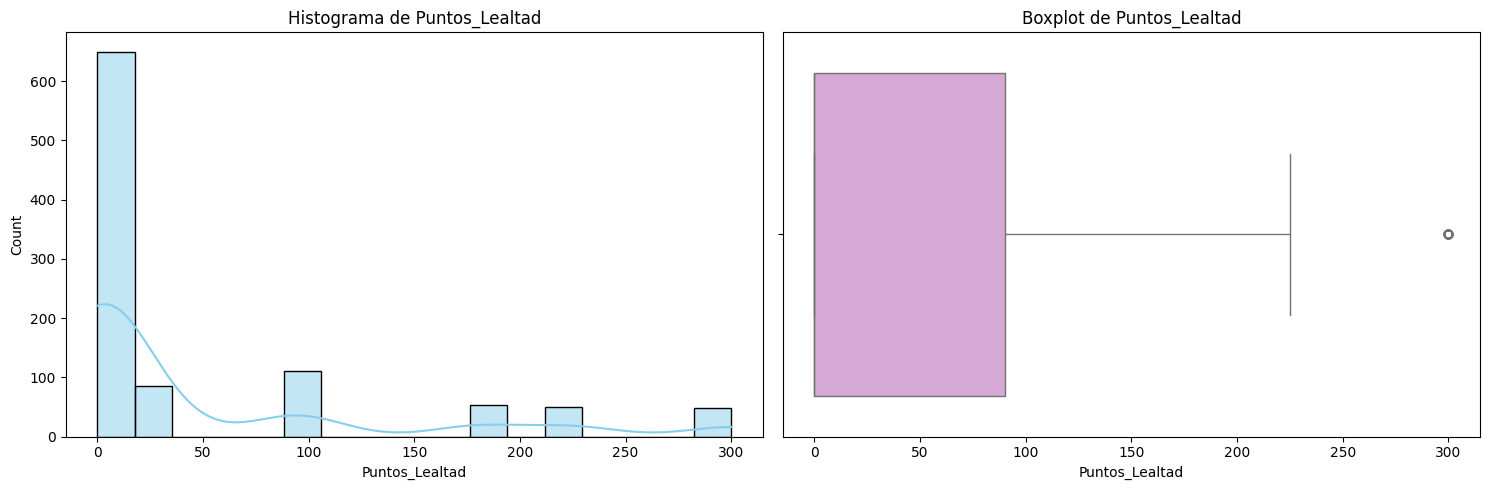

--- ANÁLISIS DE GESTIÓN: PUNTOS_LEALTAD ---
ESTRATEGIA: Media de lealtad 49.8. Rediseñar incentivos urgentemente.
TÁCTICA: El cliente top tiene 300.0 puntos. Fidelizar este segmento específico.
OPERACIÓN: Reforzar beneficios en caja para subir la mediana actual de 0.0 puntos.


In [ ]:
# Visualización
modulo_p4.graficar_distribucion_y_outliers(datos, 'Puntos_Lealtad')

# Variables para interpretación
media_puntos = datos['Puntos_Lealtad'].mean()
max_puntos = datos['Puntos_Lealtad'].max()
mediana_puntos = datos['Puntos_Lealtad'].median()

print(f"--- ANÁLISIS DE GESTIÓN: PUNTOS_LEALTAD ---")
print(f"ESTRATEGIA: Media de lealtad {media_puntos:.1f}. {'Programa sólido' if media_puntos > 50 else 'Rediseñar incentivos urgentemente'}.")
print(f"TÁCTICA: El cliente top tiene {max_puntos} puntos. Fidelizar este segmento específico.")
print(f"OPERACIÓN: Reforzar beneficios en caja para subir la mediana actual de {mediana_puntos:.1f} puntos.")

In [7]:
max_puntos = datos['Puntos_Lealtad'].max()
p75 = datos['Puntos_Lealtad'].quantile(0.75)

print(f"--- ANÁLISIS DE OUTLIERS: PUNTOS_LEALTAD ---")
print(f"ALERTA: Se detectó un valor atípico de {max_puntos} puntos.")
print(f"ESTRATEGIA: No eliminar. Este outlier representa el 0.1% de clientes VIP.")
print(f"TÁCTICA: Crear un 'Cluster Gold' para usuarios con más de {p75 * 1.5:.0f} puntos.")

--- ANÁLISIS DE OUTLIERS: PUNTOS_LEALTAD ---
ALERTA: Se detectó un valor atípico de 300.0 puntos.
ESTRATEGIA: No eliminar. Este outlier representa el 0.1% de clientes VIP.
TÁCTICA: Crear un 'Cluster Gold' para usuarios con más de 135 puntos.


5) Tendencia Temporal de Ventas

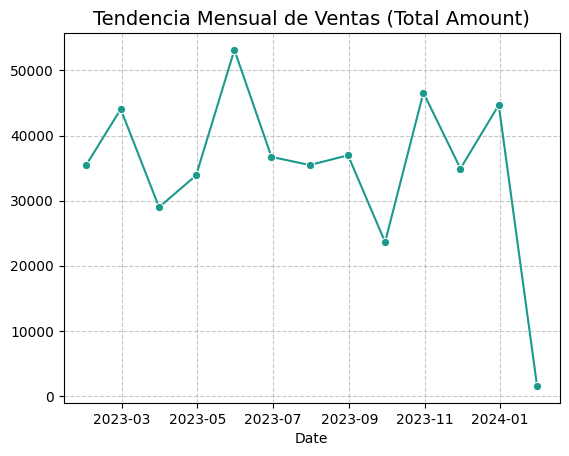

--- ANÁLISIS DE GESTIÓN: TENDENCIAS ---
ESTRATEGIA: El ingreso total acumulado es de $456,000.00.
TÁCTICA: El pico de ventas ocurrió en May 2023.
OPERACIÓN: El valle se registró en January 2024.


In [ ]:
# Visualización
ventas_mensuales = modulo_p4.graficar_tendencia_temporal(datos)

f_max = ventas_mensuales.idxmax()
f_min = ventas_mensuales.idxmin()
total = ventas_mensuales.sum()

print(f"--- ANÁLISIS DE GESTIÓN: TENDENCIAS ---")
print(f"ESTRATEGIA: El ingreso total acumulado es de ${total:,.2f}.")
print(f"TÁCTICA: El pico de ventas ocurrió en {f_max.strftime('%B %Y')}.")
print(f"OPERACIÓN: El valle se registró en {f_min.strftime('%B %Y')}.")

6) Relación entre variables

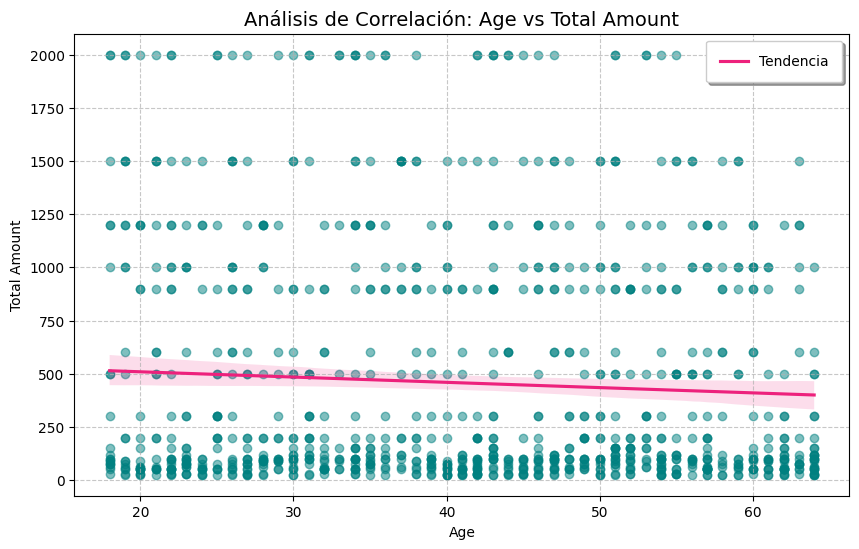

--- ANÁLISIS DE GESTIÓN: RELACIÓN EDAD VS GASTO ---
ESTRATEGIA: El coeficiente de correlación es -0.06.
TÁCTICA: No hay una relación lineal clara entre edad y gasto.
OPERACIÓN: El marketing debe ser masivo, la edad no define el gasto actualmente.


In [15]:
# Visualización y cálculo de correlación
coef_corr = modulo_p4.graficar_relacion_variables(datos, 'Age', 'Total Amount')

# Variables para interpretación
print(f"--- ANÁLISIS DE GESTIÓN: RELACIÓN EDAD VS GASTO ---")
print(f"ESTRATEGIA: El coeficiente de correlación es {coef_corr:.2f}.")
print(f"TÁCTICA: {'Existe una relación directa: a mayor edad, mayor gasto.' if coef_corr > 0.3 else 'No hay una relación lineal clara entre edad y gasto.'}")
print(f"OPERACIÓN: {'Enfocar marketing en rangos de edad específicos.' if abs(coef_corr) > 0.3 else 'El marketing debe ser masivo, la edad no define el gasto actualmente.'}")

7) Distribución de Ventas y valores atípicos

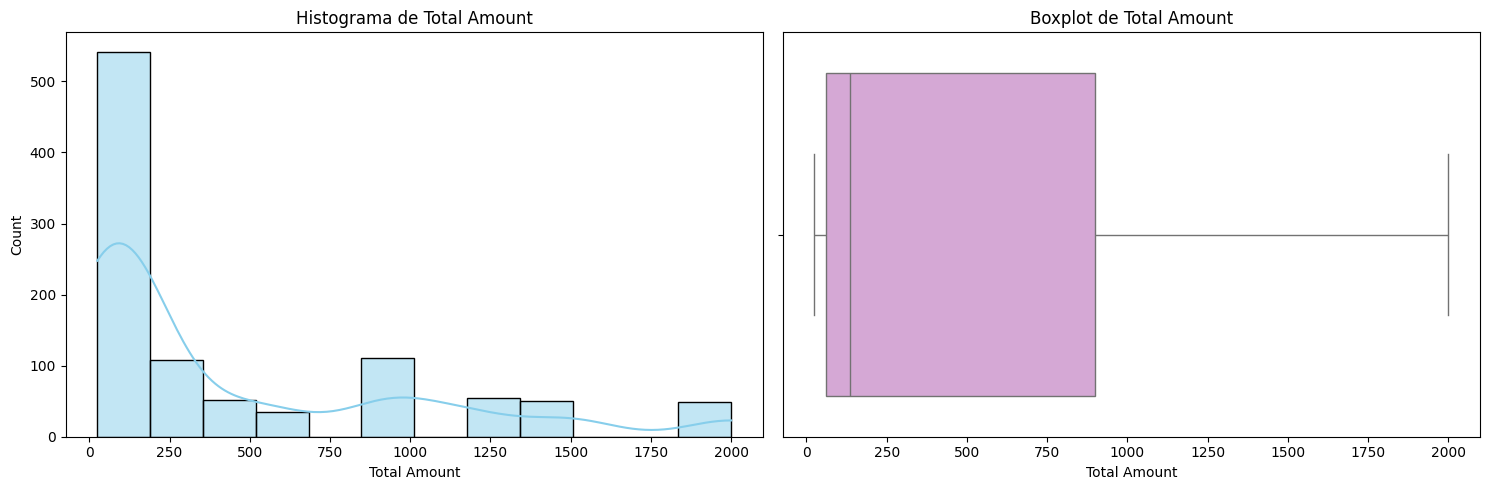

--- ANÁLISIS DE DISTRIBUCIÓN: TOTAL AMOUNT ---
ESTRATEGIA: La media de ventas es $456.00 y la mediana es $135.00.
TÁCTICA: Existe un sesgo; pocos clientes generan gran parte del ingreso.
OPERACIÓN: El límite máximo es $2000.00. Se recomienda auditar transacciones que superen los $2135.99.


In [ ]:
# Visualización y obtención de estadísticas
stats = modulo_p4.graficar_distribucion_y_outliers(datos, 'Total Amount')

# Variables para interpretación
media = stats['mean']
mediana = stats['50%']
max_val = stats['max']

print(f"--- ANÁLISIS DE DISTRIBUCIÓN: GASTO TOTAL ---")
print(f"ESTRATEGIA: La media de ventas es ${media:.2f} y la mediana es ${mediana:.2f}.")
print(f"TÁCTICA: {'La distribución es equilibrada' if abs(media-mediana) < (media*0.1) else 'Existe un sesgo; pocos clientes generan gran parte del ingreso'}.")
print(f"OPERACIÓN: El límite máximo es ${max_val:.2f}. Se recomienda auditar transacciones que superen los ${media + 3*stats['std']:.2f}.")